# ⚾ Swing-and-Miss EDA
**DSC 148 — Course Project**

Exploratory analysis of Statcast pitch data from Baseball Savant.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from src.data_loader import load_processed
from src.feature_engineering import build_features

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (10, 5)

In [3]:
df = load_processed()
print(f'Pitches: {len(df):,}')
print(f'Columns: {df.shape[1]}')
df.head(3)

Pitches: 1,464,859
Columns: 29


,game_date,pitcher,batter,game_pk,at_bat_number,pitch_number,release_speed,release_spin_rate,release_extension,release_pos_x,...,pitch_name,balls,strikes,stand,p_throws,description,type,events,swinging_strike,pitch_family
0,2022-04-26,663776,664702,661032,1,1,94.7,2105,6.1,1.92,...,4-Seam Fastball,0,0,R,L,ball,B,None,0,FF
1,2022-04-26,663776,664702,661032,1,2,94.6,2131,6.1,1.77,...,4-Seam Fastball,1,0,R,L,called_strike,S,None,0,FF
2,2022-04-26,663776,664702,661032,1,3,83.3,2894,6.1,1.69,...,Curveball,1,1,R,L,called_strike,S,None,0,CU


## 1. Class Distribution

Overall swinging strike rate: 12.26%


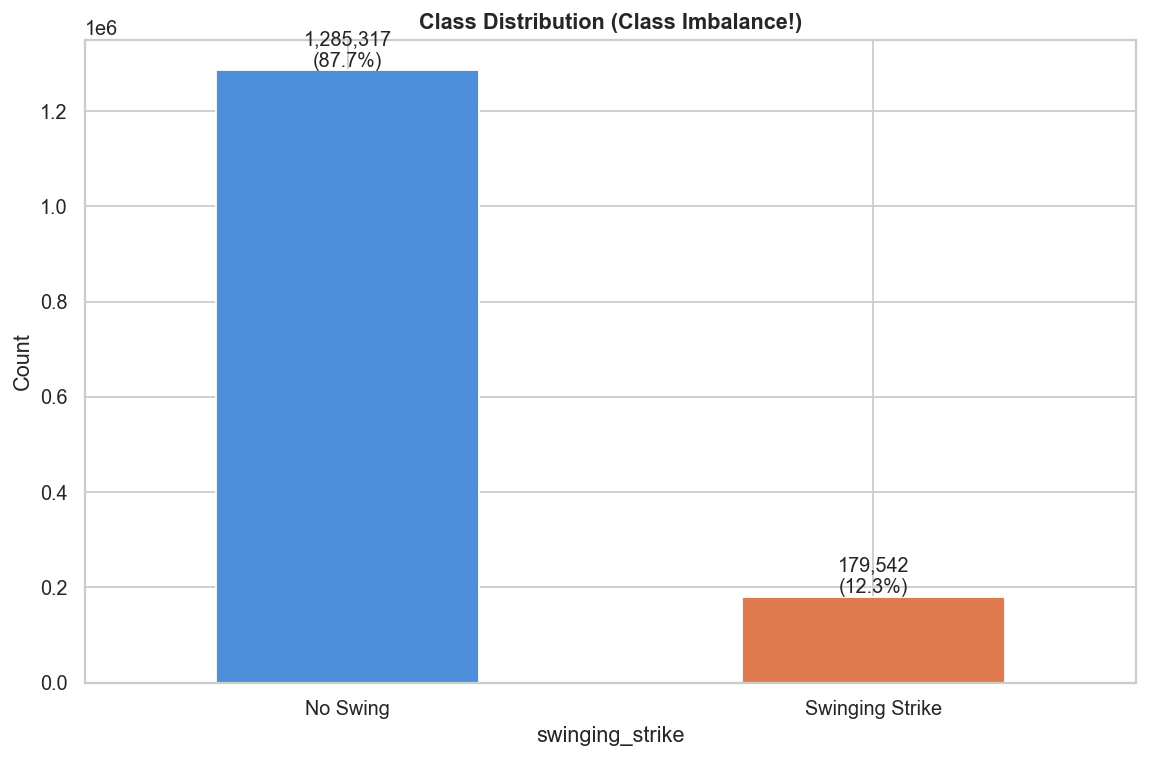

In [13]:
rate = df['swinging_strike'].mean()
print(f'Overall swinging strike rate: {rate:.2%}')

fig, ax = plt.subplots(figsize=(9, 6))
df['swinging_strike'].value_counts().plot.bar(
    ax=ax, color=['#4C8EDA', '#E07B4F'], edgecolor='white'
)
ax.set_xticklabels(['No Swing', 'Swinging Strike'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Class Distribution (Class Imbalance!)', fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}\n({p.get_height()/len(df):.1%})',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()

## 2. Swinging Strike Rate by Pitch Type

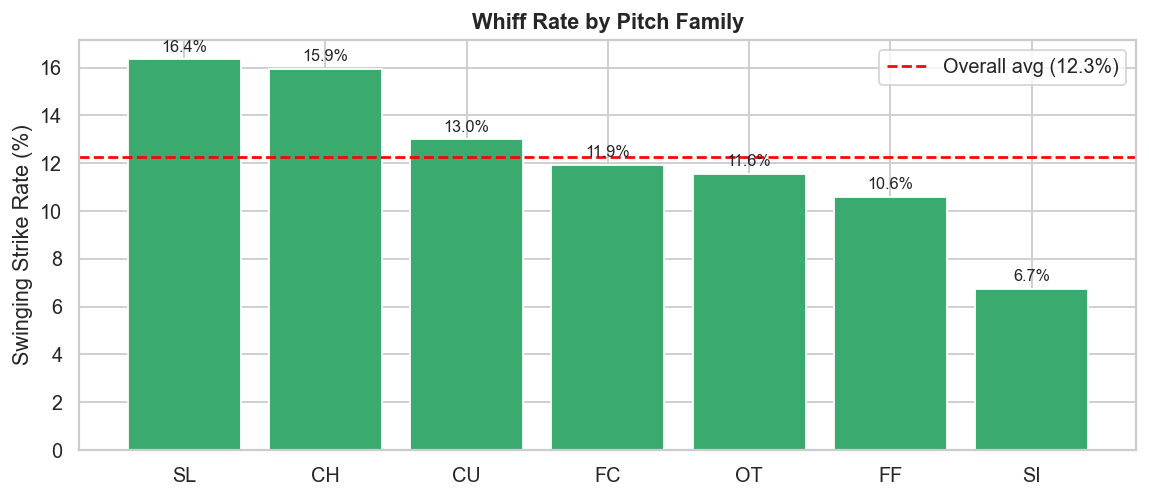

In [5]:
pitch_stats = (
    df.groupby('pitch_family')['swinging_strike']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'whiff_rate', 'count': 'n'})
    .query('n > 1000')
    .sort_values('whiff_rate', ascending=False)
)
pitch_stats['whiff_rate_pct'] = pitch_stats['whiff_rate'] * 100

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(pitch_stats.index, pitch_stats['whiff_rate_pct'],
              color='#3BAA6E', edgecolor='white')
ax.axhline(rate * 100, color='red', ls='--', lw=1.5, label=f'Overall avg ({rate:.1%})')
ax.set_ylabel('Swinging Strike Rate (%)')
ax.set_title('Whiff Rate by Pitch Family', fontweight='bold')
ax.legend()
for bar, (_, row) in zip(bars, pitch_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{row['whiff_rate_pct']:.1f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()

## 3. Velocity Distribution by Pitch Type

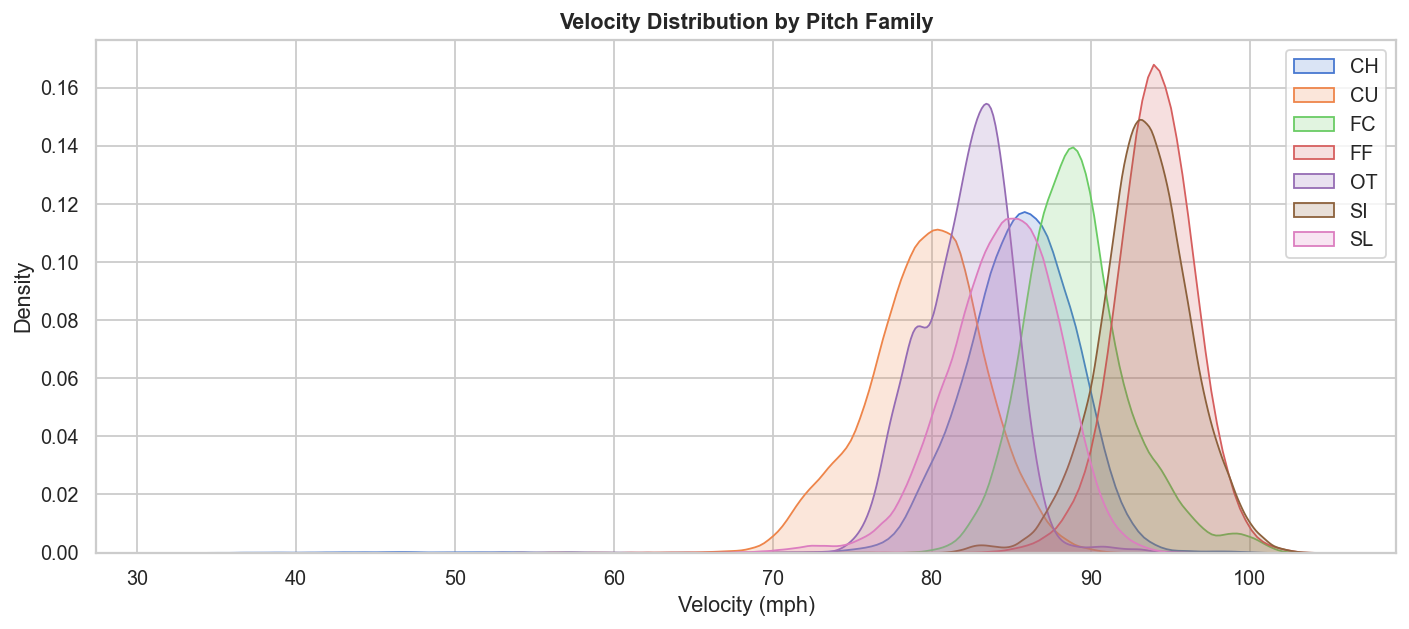

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
for family, grp in df.groupby('pitch_family'):
    if len(grp) > 5000:
        sns.kdeplot(grp['release_speed'], ax=ax, label=family, fill=True, alpha=0.2)
ax.set_xlabel('Velocity (mph)')
ax.set_ylabel('Density')
ax.set_title('Velocity Distribution by Pitch Family', fontweight='bold')
ax.legend()
plt.tight_layout()

## 4. Pitch Location Heat Map (Swinging Strikes)

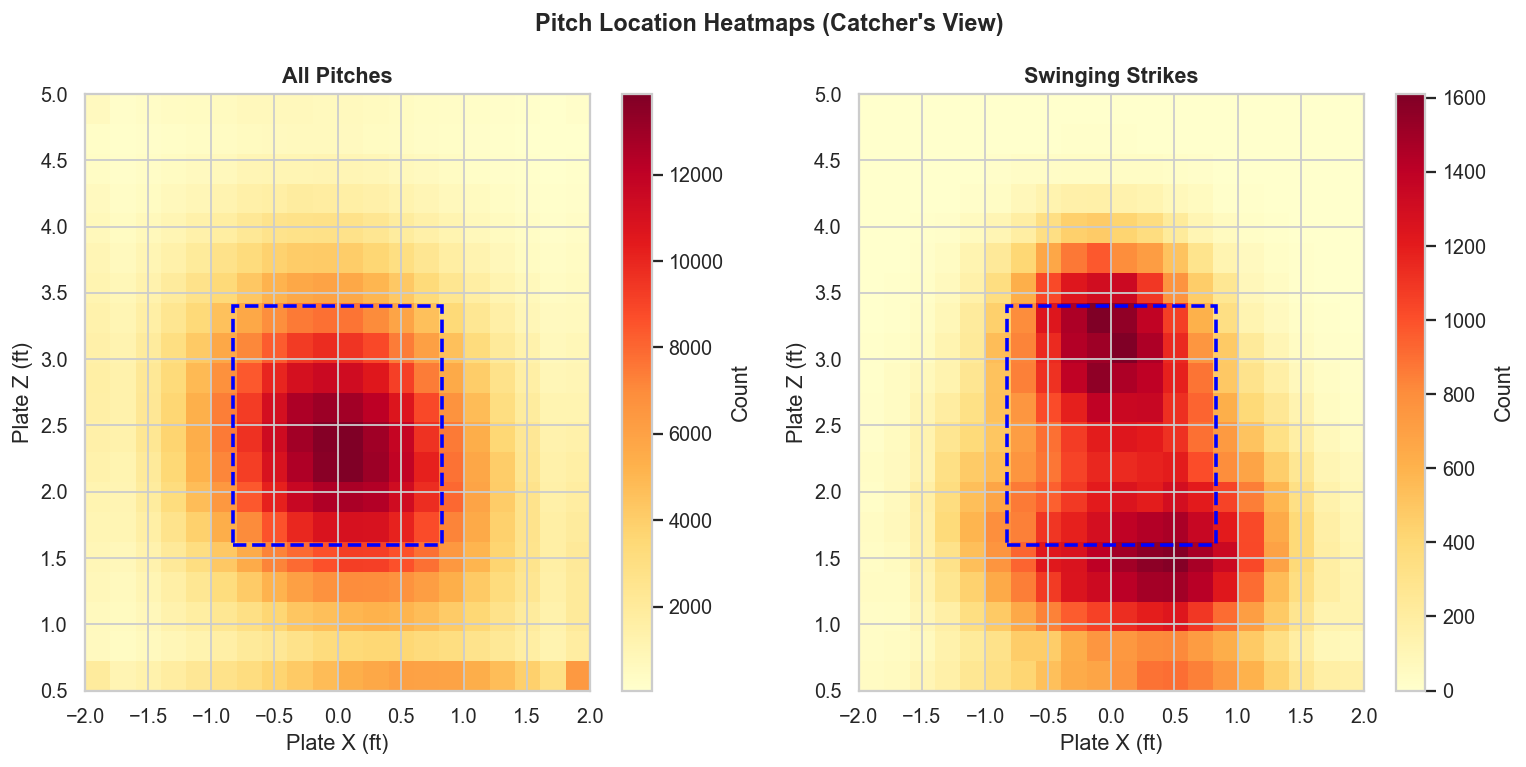

In [7]:
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Bin into 20x20 grid
bins = 20
x_range = (-2, 2)
z_range = (0.5, 5)

for ax, (label, subset) in zip(axes, [('All Pitches', df), ('Swinging Strikes', df[df['swinging_strike']==1])]):
    h, xedges, yedges = np.histogram2d(
        subset['plate_x'].clip(*x_range),
        subset['plate_z'].clip(*z_range),
        bins=bins,
        range=[x_range, z_range]
    )
    im = ax.imshow(h.T, origin='lower', aspect='auto',
                   extent=[*x_range, *z_range], cmap='YlOrRd')
    # Strike zone box
    rect = Rectangle((-0.83, 1.6), 1.66, 1.8, linewidth=2,
                     edgecolor='blue', facecolor='none', linestyle='--')
    ax.add_patch(rect)
    ax.set_xlabel('Plate X (ft)')
    ax.set_ylabel('Plate Z (ft)')
    ax.set_title(label, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Count')

plt.suptitle('Pitch Location Heatmaps (Catcher\'s View)', fontsize=13, fontweight='bold')
plt.tight_layout()

## 5. Swinging Strike Rate by Count

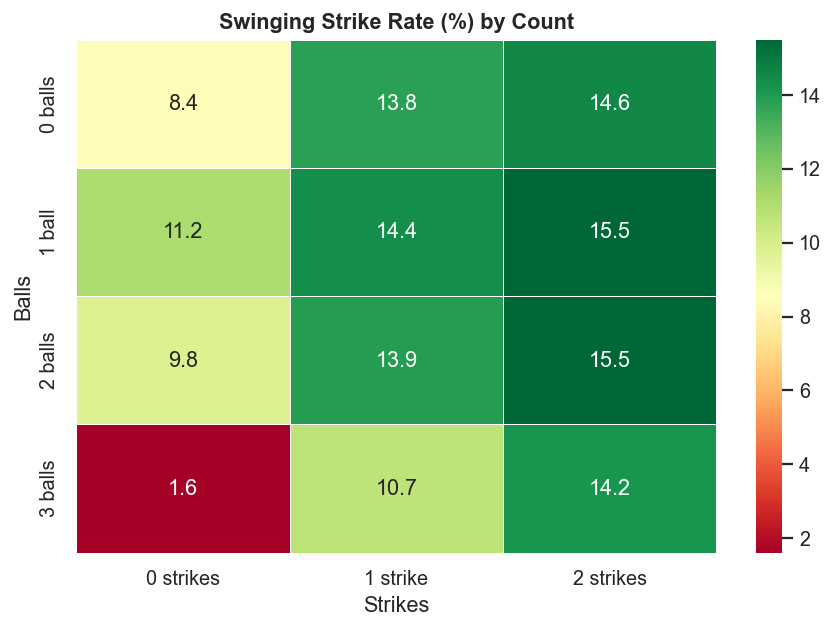

In [8]:
count_stats = (
    df.groupby(['balls', 'strikes'])['swinging_strike']
    .mean()
    .unstack('strikes')
    .loc[range(4), range(3)]
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(count_stats * 100, annot=True, fmt='.1f', cmap='RdYlGn',
            xticklabels=['0 strikes', '1 strike', '2 strikes'],
            yticklabels=['0 balls', '1 ball', '2 balls', '3 balls'],
            ax=ax, linewidths=0.5)
ax.set_title('Swinging Strike Rate (%) by Count', fontweight='bold')
ax.set_xlabel('Strikes')
ax.set_ylabel('Balls')
plt.tight_layout()

## 6. Spin Rate vs. Whiff Rate

/var/folders/j_/hjdkkc0x02dgp5m3mv6r5v9m0000gn/T/ipykernel_18440/2423080653.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['pitch_family', 'spin_bin'])['swinging_strike']


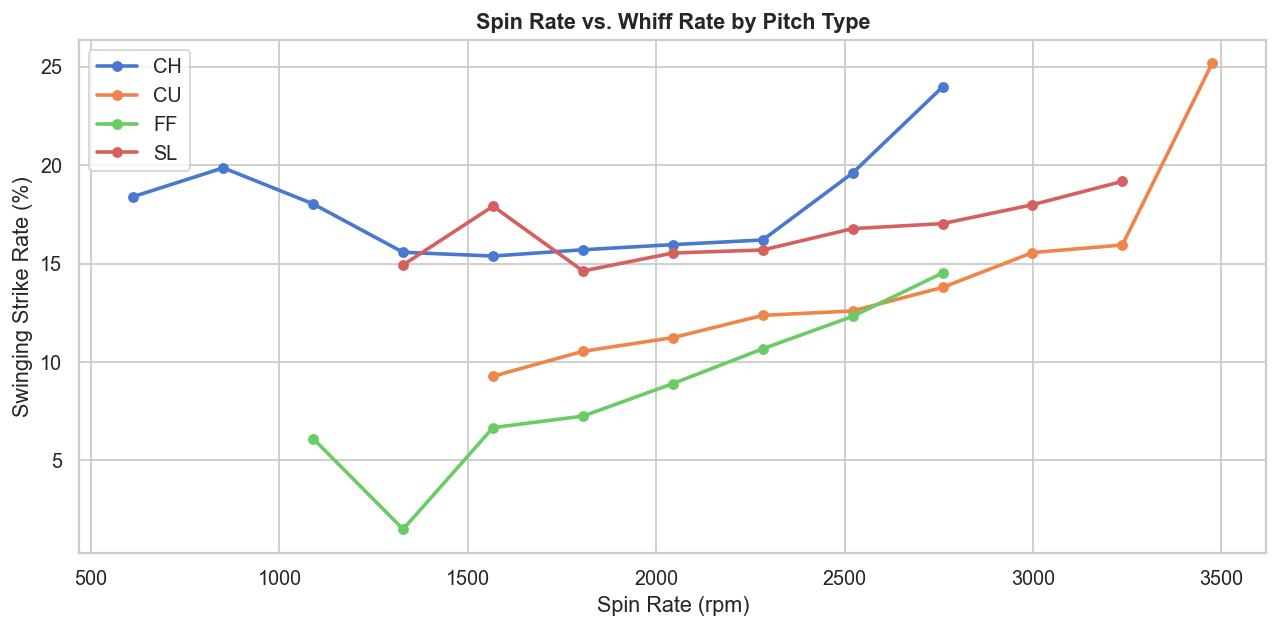

In [9]:
spin_whiff = (
    df[df['pitch_family'].isin(['FF', 'SL', 'CU', 'CH'])]
    .assign(spin_bin=lambda x: pd.cut(x['release_spin_rate'], bins=15))
    .groupby(['pitch_family', 'spin_bin'])['swinging_strike']
    .agg(['mean', 'count'])
    .query('count > 200')
    .reset_index()
)
spin_whiff['spin_mid'] = spin_whiff['spin_bin'].apply(lambda x: x.mid)

fig, ax = plt.subplots(figsize=(10, 5))
for family, grp in spin_whiff.groupby('pitch_family'):
    ax.plot(grp['spin_mid'], grp['mean'] * 100, 'o-', lw=2, ms=5, label=family)
ax.set_xlabel('Spin Rate (rpm)')
ax.set_ylabel('Swinging Strike Rate (%)')
ax.set_title('Spin Rate vs. Whiff Rate by Pitch Type', fontweight='bold')
ax.legend()
plt.tight_layout()

## 7. Feature Correlation Matrix

Building features …
  Features: 48 | Rows: 50,000 | Positive rate: 12.36%


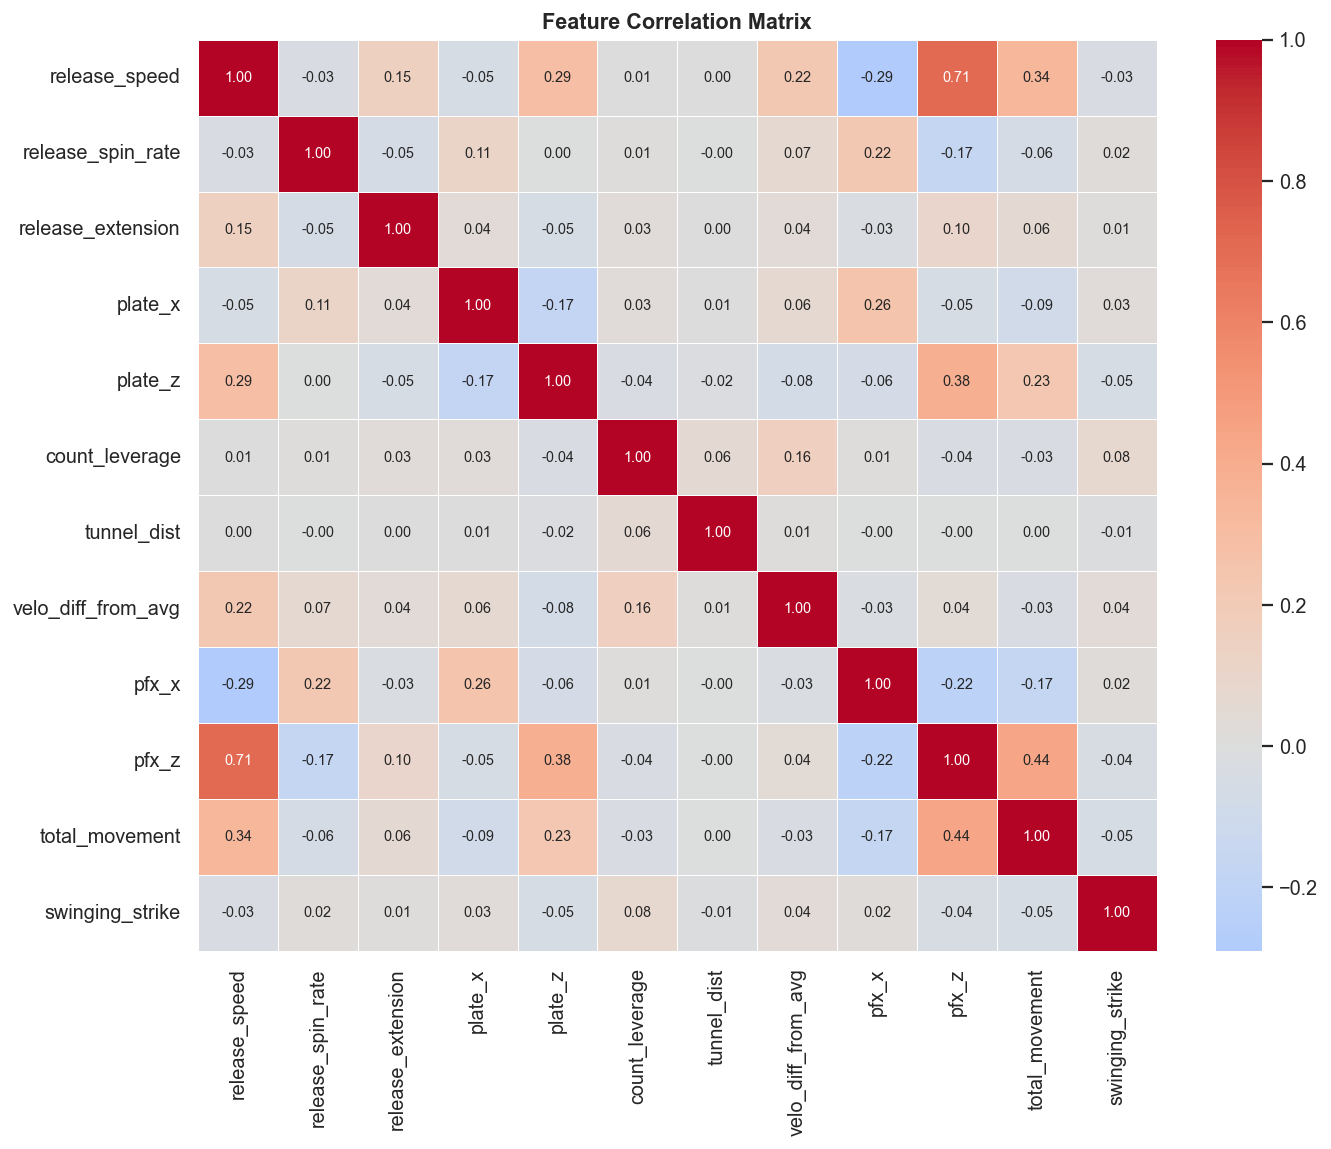

In [10]:
X, y, feat_names = build_features(df.sample(min(50_000, len(df)), random_state=42))

# Select numeric features for correlation
core_feats = ['release_speed', 'release_spin_rate', 'release_extension',
              'plate_x', 'plate_z', 'count_leverage', 'tunnel_dist',
              'velo_diff_from_avg', 'pfx_x', 'pfx_z', 'total_movement']
core_feats = [f for f in core_feats if f in X.columns]

corr = X[core_feats].assign(swinging_strike=y).corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()

## 8. Handedness Analysis

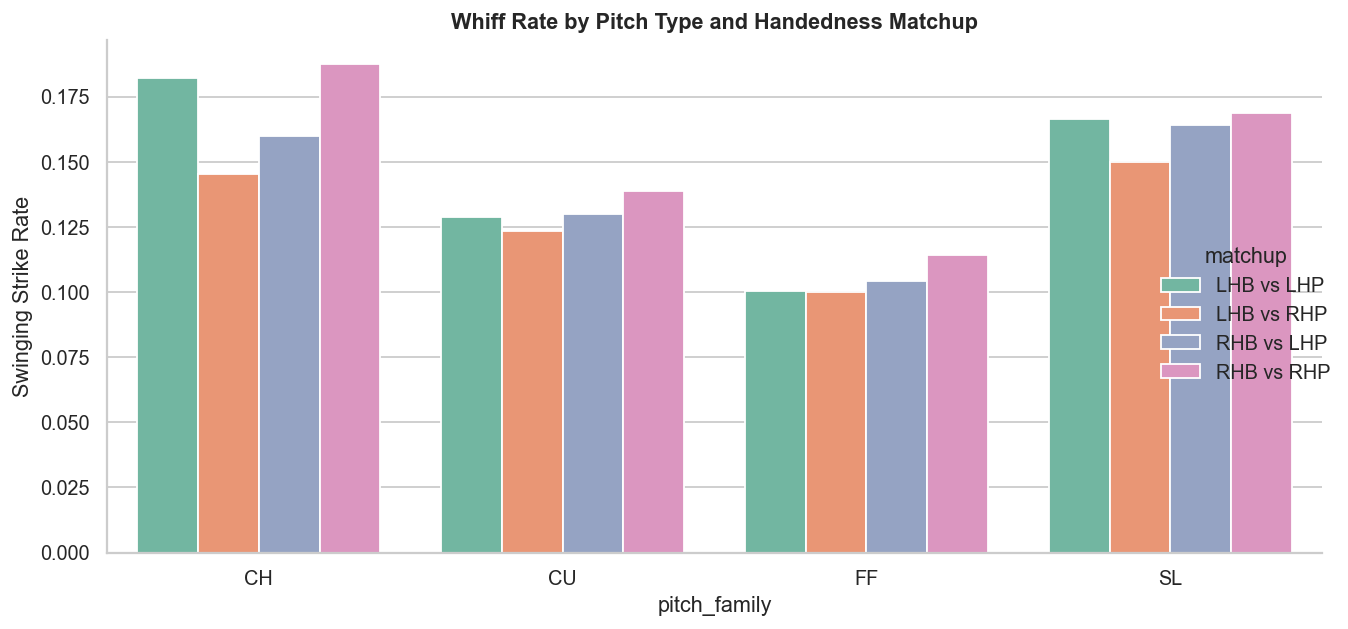

In [11]:
hand_stats = (
    df.groupby(['stand', 'p_throws', 'pitch_family'])['swinging_strike']
    .mean()
    .reset_index()
    .rename(columns={'swinging_strike': 'whiff_rate'})
    .query('pitch_family in ["FF", "SL", "CU", "CH"]')
)
hand_stats['matchup'] = hand_stats['stand'] + 'HB vs ' + hand_stats['p_throws'] + 'HP'

g = sns.catplot(
    data=hand_stats, x='pitch_family', y='whiff_rate',
    hue='matchup', kind='bar', height=5, aspect=1.8,
    palette='Set2', edgecolor='white'
)
g.ax.set_ylabel('Swinging Strike Rate')
g.ax.set_title('Whiff Rate by Pitch Type and Handedness Matchup', fontweight='bold')
plt.tight_layout()